# Author: Husam Abdelrahim

## Project 4: Predictive Analysis using scikit-learn

## Introduction:

When it comes down to mushroom foraging we know that it's actually a very popular activity in the activity of recreation, it is a very important part and critical aspect and it's practiced in many different countries that is around the world. However, one must keep in mind is that when working in this sort of field it's very important take safety and as we uncovered the attribtues that the mush possess, we know that some of the mushroom edible but what makes it so dangerous is that they could be very toxic if the analyzation is not fully observered, if one decides to consume a mushroom that shows high evidence of toxicity then it could lead to results to fatal. So our goal is to basically to understand the attribtues that is being provided and understand with what is edible and what is poisonous and how to know if it's safe to consume or not. With the ability of actually getting to understand the attributes we can have a better understanding of the mushroom 

So in this analysis with what I am going to be doing is that we will continue to build from the previous work that I have proved in week 12 assignment, in that work to revisit I have managed to prepare and basically actually explore the mushroom dataset that was provided by the UCI. Now what we are gonna do is that we are gonna leverage the techniques of the machine learning with the use of **scikit-learn** and what this is going to be doing for us is that it's going to be creating a model that would help us reveal and determine the edibility and pending on the characteristics that it does come with. This basically represents a data science work that is handling with a real world problem and we use these techniques to have a better understand and laying out the foundation.

So what the key objective is that this analysis will continue to include:

- We are going to be building a machine learning model that is going to basically classify if the mushroom is actually edible or if it's poisonous

- We are going to evaluve the feature like which is going to be the most predictive and this is going to be coming in with odor and the spore print color 

- We are going to be assessing and finding out hte accuracy pending of the predictive model that we continue to use. 

- I'm going to basically determine the specific charateristics that also more associated with toxicity 

- Lastly I want to be able to display insights and how we can understand mushroom attributes much more better and the practices that do come with it.

By having the ability to learn meachine learning what is going to do for us is that it's going to display on how a data driven work can really give us information on what is the most dangerous mushroom, what attributes they have, and also understand the identifcation that comes with the mushroom

# Step 1: Getting the evnironment and the importing libaries for the work 

What this step is going to be doing for me is that we need these tool to actually make work, these python packages are very critical for our work:

- **pandas**: Pandas is a really critical tool to utilize in our data and a helpful analysis tool
    - The DataFrame Structure that is being provided is going to be very crtiical especially when it comes down for storing and being able to manipulate mushroom data
    - This is going to basically be ver yefficent for the transformation of the data 

- **skilearn.model_selection:** This is going to be containing tools for the splitting the datasets that is being provided in my work 
    - What the **train_test_split** function will allow me to do is create the training and the testing datasets but seperate
    - This is going to be very critical in our work especially with the model evaluation

- **sklearn.tree**: This is going to be containing the tree based classifcation algorithm
    - **DecisionTreeClassifier** - what this will be doing for us is that it's going to provide a model that interpretable and also that is suitable for the categorical data that we are working with
    - This is actually very well suited especially for the problems and the the important analysis that is going to be made

- **sklearn.metrics**:  This is basically goint to provide an evaluation of the metrics when it comes down to the machine learning model
    - **accuracy_score** it's basically going to be calcualtion the proportion of the classifeid instances
    - **classification_report** is going to be generate an info of the metrics especailly with getting the score

- **matplotlib**: Of course what this is going to be doing for us is creaate visualization which is used to demostrate our work 
    - This is going to basically help us generate a bar and feature the importance
    - This is going to help us with our findings with the use of graph!

In [1]:
# In this section what is going to hapen is that we are going to be running necessary libaries that is going to be important for us to utilize in our work 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

## Step 2: Loading the data and preping the data

In this process what is going to be done is that it's going to processing our draw data and we are going to be preparing it for analysis:

**column definition** : So as previously stated we are going to be define the 23 columns that is being presented from the UCI dataset of the mushroom
    - This is going to be providing a structure with the data that is unlabeled 
    - While there is going to be 3 columns that is going to be used throughout the work, we are going to defining the columns and make sure that the data that we are working with is properly working

**Loading the data**: In this section we are going to be doing is loading the data and make sure that we are going to be reading the csv files that is provider and in this part of the work what is going to be done is that the header =None is basically saying that it doesn't have a header row and teh column names is currently assigned depending with our list that is being provided in the work

- **Feature Selection**: Now what isdone in this step is that we are going to be extracting the three analysis from this daya that we are working worth
    - **class (edibility)**
    - **odor**
    - **spore_print_color**


To basically describe with what is going on the ediblity is going to be our target variable and basically this is going to display if the mushroom that we have here is either mushroom or posionous and then the odor is basically going to be show the identification of the smell and the spore print color is basically going to be left behind especially when it comes down to the spore being put on the white paper.

Lastly we have the **column renaming** : We had to rename the column to have a better name so for example the world **class** would become **ediblity** and this is being done for clarity purposes and then we have the **spore-print-color** that is going to be **spore_print_color** the reason why we do this is actually for python purposes and easier for python to handle! 

In [2]:
# In the second section what is going to happen is that we are going to loading the dataset, this is the data set from the previous assignment that I have provided in my recent work

column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color',
    'population', 'habitat'
]

# Now what I am going to be doing is that I am going to be loading the data same as previous of course

data = pd.read_csv('agaricus-lepiota.data', names=column_names, header = None)

# what is going to  happen here is that I am going to basically utilize the same columns as I did with my last assignment since I am basically using the same data set!

subset_data = data[['class', 'odor', 'spore-print-color']].copy()
subset_data.columns = ['edibility', 'odor', 'spore_print_color']

# Step 3: Coverting the code values and having it to have a much more meaningful names

This section is also going to be very critical so basically what I will be doing is basically take the single character code and give it a much more interpretable value 

**The mapping creation**: What we have done here is that we define the dictionaries that is provided and gave it more of a meaning and make it much more easier to process for example what we would have here is that **edibility**:**e** -> **edible** and **p** -> **poisonous** Now moving on to the **odor** bascially this is going to haven nine different odor that would having the meaningful names and then **spore_print_color**: which basically the nine color that are mapped to an actual color name

**Data transformation**: What is going to be occured here is that we are going to be applying the mapping to each of the column that is provided so the **.map()** method will be replacing the codes that is currently corresponding the meaningful value and this is going to be basically enchance the interpretability of the data that we currently have

**Domain knoweldge integration:** In this step it's also going to have incorporate the knowledge when it comes down to the mycological
- Odor descriptions for example would have "almod" and "anise" that would usually align with the mushroom charateristics that we are working with 

- The colors name would usually reflect the appearance of the spore prints as well

**The advantanges of the meaningful label**
So I am going to be making the data to be more accessible and pretty get the data ready to have for the non technical stakeholders, and I'm going to also be 

In [3]:
# now what is going to be doing here just the same thing of what I did in the last assignment I am going to be presenting meaningful codes 

name_mappings = {
    'edibility': {'e': 'edible', 'p': 'poisonous'},
    'odor': {
        'a': 'almond', 'l': 'anise', 'c': 'creosote', 'y': 'fishy',
        'f': 'foul', 'm': 'musty', 'n': 'none', 'p': 'pungent', 's': 'spicy'
    },
    'spore_print_color': {
        'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate',
        'r': 'green', 'o': 'orange', 'u': 'purple', 'w': 'white', 'y': 'yellow'
    }
}

for column, mapping in name_mappings.items():
    subset_data[column] = subset_data[column].map(mapping)


## Step 4: We are going to be creating a target variable and this is going to be for the machine learning that is provided

- **Binary encoding**: What is going to happen here is that we are gonna transform the categorical target and this is going to be into the numeric form

    - **edible** these are the mushrooms are encoded as 0
    - **poisonous** the mushrooms are going to be encoded as 1

**The purpose**: this step is going to be very necessary because the machine learning is going to require numeric inputs and teh also the binary classifcation problem is going to be using the 0 and 1 values and it's also going to be establish a purpose where as the number 1 would be reflect the represent of the postiive lcass of the poisonous

**The implementation**: So I'm going to be using teh pandas .map() method
- It's going to be creating a column that is basically with the **edibiltiy_numeric** with the encoded values that we currently have
- Next what is going to be disabled is that I am going to basically have the origianl 'ediblity' column that is going to be coming with the descriptive labels
- Maintaining the data integrity by basically obtaining from the the values of the original data set

**significance**: This encoding what it's going to be do for us is that it gonna help with our model to basically calulate the probabilites of the mushroom and see the poisonous and then we are going to be applying the appropriate classifcation and be able to produce a binary predictions form this work thati s being provided 

In [4]:
# Now what is going to be done here is that I am going to be creating a numeric target variable

subset_data['edibility_numeric'] = subset_data ['edibility'].map({'edible': 0, 'poisonous': 1})

## Step 5: In this step we are going to be creating the feature when it comes down to the machine learning and enable to put in One Hot Encoding

So in this step I am going to be presenting 5 essential key notes that we are going to follow The key notes is basically

- **One-Hot Encoding**
- **Feature creation**
- **Target vector extraction**
- **Dimensionality verifcation**
- **Understanding the benefits when it comes down to the one hot encoding.**

For the **one-hot encoding** what it's going to be doing for us is that is going to help convert the variables and turning them into a much more refined binary vectors, another note that could be made here is that the values is going to become it's own column and this is the feature part, and when it comes down to the column it's actually going to corresponsd to teh category that gets a value of 1 while all other will be getting the result of 0 and let me provide an example

**Example**: 'odor_almond' will basically have a column that will continue to have 1 mushroom and almond odor, however for the rest of the mush it going to be displaying a 0 for all of the others 

Next we have the **Feature creation** and basically this is going help us use the pandas method which is the 'get_dummies()' and what this does for us is that it's going to be creating a new DataFrame for 'x' and it's going to be coming with the binary columns for each of the value that is presented and in this work there is going to be 9 odor with 9 spore colors and that is going to equal to 18 binary features that is going to be presented and each of the mushroom will have two 1's and one of them is going to be for the odor and the other one is going to be for the spore color

**Target vector extraction**: Our target vectory is basically going to be assigning to the numertic target which is going to the variable 'y' and this is going to be containing 0 for the edible and while 1 is going to be for poisonous mushroom

For the **Dimensions** to understand teh feature that is going to come with it's basically features: 

- The features is that : (8124, 18) = 9,124 mushroom that is going to coming with the 18 binary features

- The target is basicall going to be: (8124,) = 8,124 edibility labels 

- This is going to confrim the transformation that is basicalyl mainted the oberservations making sure that its original

With the **benefits of the one hot encoding**: what this is going to be doing for us is that it's going to basically it going ot make sure that the algorithms will not be misinterpreting the categorical values and making it seem that it's ordinal, making out feature be more expressive and this is going ot be for our classifcation problems and lastly it's going to be allowing our model to learn the impact that each of the category level 


In [5]:
# Now what we are going ot be doing is that we are going to be creaitng a one hot cencoded features and this is with using pandas of course and we have to use the get_dummies (as it has been stated in the assignment)

x = pd.get_dummies(subset_data[['odor', 'spore_print_color']])
y = subset_data['edibility_numeric']

print("Features shape:", x.shape)
print("target shape:", y.shape)


Features shape: (8124, 18)
target shape: (8124,)


## Step 6: Split the data and the train decision with the tree model that is provided to us

What this step is going to involde for us is that it's going to training the machine learning model and getting to evaluate the performance:

We know that we are data that is going to be allocated for the training and reserved for test testing and to explain owhat **random_state=42** does ofr us is that it makes sure that the reproducbility of the split is there and then we are going to be having the separation that is going to allow for honest performance

Understanding the the **model** in my work let's talk about decision tree caller and what this does for us is that it's basically very well suited when it comes down to the categorical data and then the model continues to uses binary decision to help us with separaing the classes, now in terms of **model training** this model is going to help to learn the patterns especially when it comes down to the odor and the spore print when it comes down to the eidiblity, the tree structure that we have here is basically opimizied with the recursive partitioning of course and then when it comes down to the **prediction** we are basically going to be applying the a train model for the test data that we have, the model is going to predict the edilibty from 0 or 1 and this is going to be for each of the mushroom in the test set, what these predictions will do for us is that it's going to compare against known values

In terms of the **the performance evauation** we start to calcualte the the accuracy and the detailed metrics that we have here and the overall accuracy: 99.34% and this does display a high amount of success. With the classfiication report that we have is that the mushrooms being predicted either with edible or poisonous and what of the percentage is actually coorrect, we are also going to recall the edible and the poisonous mushroom.

**The key results that is presented:**

- We notice that there is a near perfect especially when it comes down with both of the edible and the poisonous classes
- There is a balanced performance when it comes down to the dible and the poisonous classes
- We have high preciosion especially when ti comes down for the poisonous classification and this is pretty cricitcal 

In [6]:
# In this section what is going ot happen is that we are going to be spllitting the data with the training and the testing sets that is provided

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# now we are going to be creating we are also gonna train the decision tree classifier 

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

# In this step what is going to be done is that we are going to be making the predictions

y_pred = model.predict(x_test)

# now we are going to be evaluating the model that we are going to be working with

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# displaying the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))


Model Accuracy: 0.9934

Classification Report:
              precision    recall  f1-score   support

      Edible       0.99      1.00      0.99      1257
   Poisonous       1.00      0.99      0.99      1181

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



## Step 7: In this step what what is going to happen is that we are going to extract, analyze, and understand with what the visualization is presenting to us. 

**The feature information and the extraction**: With the feature that we have here and the feauture_importances_attributes

So with this the decision trees is going to be calcualting the importance and this is going to be based on the importance of each feature which will be able to show reduces impurity, and with the higher value it going to be indicating feature and be able to contribute to a prediction accuracy, with the sum that we are working with 1.0 it's going to be representing percentage importance

**Data organization**: In this area I am going ot be creating a DataFrame with features and try to understand the importance score that is being provided

- Columns that is going to be including the feature of the name and the value importance
- I am going to be sorting by the importance and help us with identifying the predictors 
- This structure format is going to be enable the analysis and the visualization

**Top features**: We are going to be displaying the 10 most important features and this is going to come with 

- Results is going to be showing the "odor_none" this is going to be one of the most critical feature that we have displayed with a result of = 0.64

- "odor_anise" which shows a result of 0.16 and the odor_almond which shows a result of 0.15 which is pretty significant

- with the "spore_print_color_green" does have a modernate imporance with the the result of 0.03

- Thereare many features that show importance what this tells us and that there isn't much of a predictive value to really go by

**Visualization:**

- In this process the bar lengths is basically going to be represetning a relative importance of the each feature that is provided
- This is basically going to be oredered from most to the least important that we have here and the with these visuals it's going to make us understand the attribtures a lot more

**Key notes**

So the information that I would like to display is that the features is going to to help us showing with how dominate the decision making process, we also see that the absence of the odor that is being presented shows the a strong edibility of the predictor, most of the features that we have here are minimal or don't really have a importance factor to the model that we are working with, this model does relies on the few key features that is presented in the work. Another analysis that we can make is that the spore print colors are somewhat less signifcant then the odor charateristics and then teh odor types doesn't really have any important and that is because the perfect correlation that is being presented with the dibiltiy. 


The Top 10 of the Most Critical Features Provided:
                    Feature  Importance
6                 odor_none    0.643603
1                odor_anise    0.170988
0               odor_almond    0.150387
13  spore_print_color_green    0.033667
16  spore_print_color_white    0.001355
2             odor_creosote    0.000000
5                odor_musty    0.000000
7              odor_pungent    0.000000
4                 odor_foul    0.000000
3                odor_fishy    0.000000


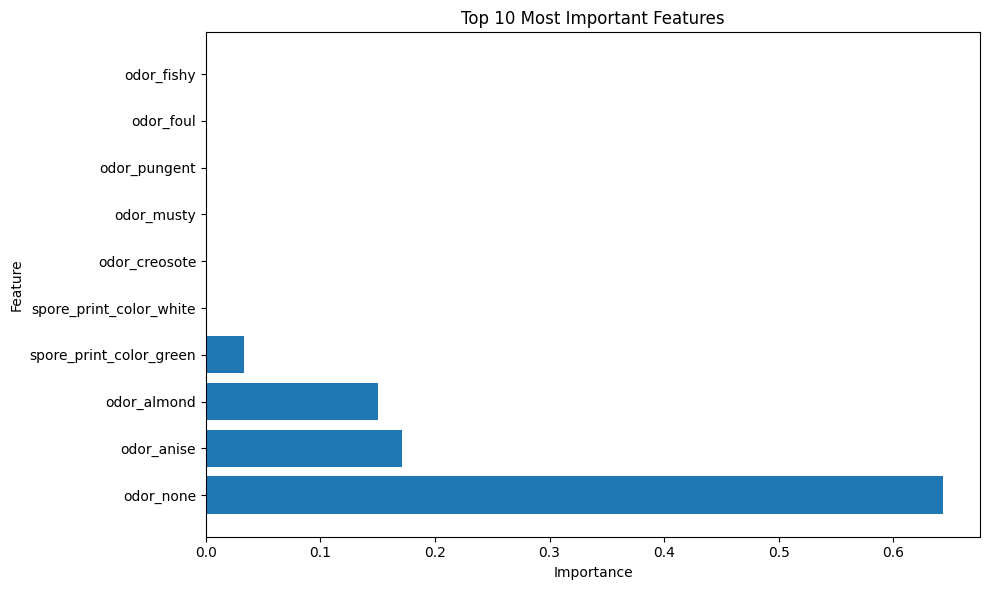

In [7]:
# what is going to be done is that we are going to feature the importance

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Now what we are going to be done is that we are going to be dislaying the top 10 important features that is provided in our work

print('\nThe Top 10 of the Most Critical Features Provided:')
print(feature_importance.head(10))

# In this section I'm going to be presting a visualization feature 

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

## Analysis and interpretation

So in teh analysis that we have managed to work with the machine learning is going to demostrate on whether if the mushroom is edible or poisonous based on the odor and the the spore print color and this is going to be displaying the result of a 99.34% which is -> 0.9934. With level of information and getting to understand with the accuracy having to provide it's really done well especially when it comes down to real world problems and with the data and the information that we have managed to collect it strongly shows the ediblity of the mushroom that is provided 

**Key findings**

**Odor dominating the predictions**:

The odor is what really dominated the prediction the the top three features that are actually odor related which we can actually see from the graph! We see it with the result of = 96% power, the absence which is the odor_none is one of the most critical features that is being displayed here with a 65% and of course alond and anise are the one of the most strongest and the most associated with the ediblity.

**The features hierarcy**:

With what this is going to be displaying for us is that:

1. **odor_none:** 0.64 and this right here like I have stated is going to be the most important predictor

2. **odor_anise:** with sitting at 0.17 - this is a nice odor and is very highly and associated with the ediblity

3. **odor_almond:** 0.15 this is another odor that is also going to be linked with the edibility

4. **spore_print_color_green:** since we now that odor is the one that is dominating the data, with the green spore print color wit's a result of 0.03 and has modest importance

5. **spore_print_color_white:** this is has zero importance to graph and it shows a 0.001

**Features that aren't really valuable**:

In this sense many of the odors such as cresote, musty, pungent, foul, and fishy they don't really have a huge factor and zero importance and these tend to indicate that those mushrooms are actually more associated with posionous mushrooms and once the model has managed to display the top predictors of the work we notice that these features don't really provide any information that we can fruther review.

**Spore color**

- The spore colors in this work is showing a substantial less power than odor

- Only the green and the white is showing measurement that we can see and utilize

- Odor is always going to be more reliable than the color when it comes down to identify the mushrooms attributes

**Implications**: 

The model is going to show a better guide and be able to select the right odors especially when it comes down to making the proper decision and have a better idea and tools to idenify.

## Conclusion

With our predictive analysis with the ability to use the scikit-learn it's giong to show with how machine learning can really effectively be able to identify the mushrooms and this is going to differate with what is edible and what is poisonous with simple observational characteristics of the mushroom. The key conclusion taht I am made from this study is:

1. **An accuracy that is achieveable**: with just odor and the spore print we can see that there the mushrooms is very accurate with the percentage of 99.34% 

2. **Odor is very dominant**: With the presence, absence, and teh quality of the odor it's going to be providing the most information when it comes down to the mushroom ediblity

3. **a subset features is sffucient**: We notice in our work that 5 out of the 18 features does tend to capture the ifnromation that is really critical when it comes down to accurate classification

4. **The absence of odor**: With the lack of information when it comes down to odor it actually gives an idea especially with the diblity than any information that is presented

5. **Odors = Edibility** odors like almond and anise scents are very highly predicitve to be an edible mushrooms

With these findings it basically provides a strong validation, with using this method we have a better understanding when it comes down to identifying the mushrooms that we are working with 0

## Recommendations for the analysis much further

To further ot exand on the work that is being provided here 

- To understand our work more we can include more chatertistics and what this will do for us is that we can see more accuracy

- The ability to analyze with the comibinations of different features see how they impact teh work and how it could possibly provide more predictice power

- The ability to test the model and see how it can really provide more information and the power

- Ability to also make tools that could really help the foragers with their analysis

- Adjusting the model and being able to prioritize any false positives of the edilibty

- Getting more data when it comes down to certain mushroom especially if they can be classifed as rare

The strong perfromance in our model and with the machine learning approaches it can continue to be more valuable if we continue to build on it and this is basically what it's going do for us is to continue enchance safety and make sure the right analysis is provided, with more information teh work could be more outstanding. 